# Synthetic cold-chain dataset report

Loads a dataset from `python -m data.generate` and renders coverage, label balance,
spoilage-risk trajectory, delivery, actions, and disruption/health diagnostics.

Set `DATASET_DIR` below to the folder with `episode_*.pkl` and `manifest.json`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "dataset.py").exists():
            return candidate
    raise RuntimeError("project root not found (data/dataset.py)")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.dataset import ColdChainDataset

DATASET_DIR = PROJECT_ROOT / "data" / "dataset"
BINS = 10

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def episodes_frame(ds: ColdChainDataset) -> pd.DataFrame:
    """One row per episode."""
    return pd.DataFrame([
        {
            "episode_id": ep.episode_id,
            "fruit": ep.fruit_type.value,
            "weather": ep.ambient_weather.value,
            "ambient_temp_c": ep.ambient_temp_c,
            "source": ep.source_node,
            "target": ep.target_node,
            "n_steps": len(ep.steps),
            "final_label": ep.final_label,
            "delivered": bool(ep.steps and ep.steps[-1].delivered),
        }
        for ep in ds
    ])


def steps_frame(ds: ColdChainDataset, bins: int = BINS) -> pd.DataFrame:
    """One row per step, with a progress-normalized bin."""
    rows = []
    for ep in ds:
        n = len(ep.steps)
        for i, step in enumerate(ep.steps):
            rows.append({
                "episode_id": ep.episode_id,
                "fruit": ep.fruit_type.value,
                "weather": ep.ambient_weather.value,
                "tick": step.tick,
                "rel_bin": min(bins - 1, i * bins // n) if n else 0,
                "spoilage_risk": step.spoilage_risk,
                "sensor_temperature_c": step.sensor_temperature_c,
                "energy_usage": step.energy_usage,
                "delivered": step.delivered,
                "n_disruptions": len(step.active_disruptions),
            })
    return pd.DataFrame(rows)

In [2]:
dataset = ColdChainDataset.from_dir(DATASET_DIR)
manifest = dataset.manifest
episodes_df = episodes_frame(dataset)
steps_df = steps_frame(dataset)

print(f"episodes: {len(dataset)}")
print(f"master_seed: {manifest.get('master_seed')}")
print(f"dataset_sha256: {manifest.get('dataset_sha256', '')[:16]}...")
if manifest.get("library_versions"):
    versions = pd.Series(manifest["library_versions"], name="version")
    display(versions.to_frame())

episodes: 100
master_seed: 0
dataset_sha256: 04acf42ac753244f...


,version
gymnasium,1.2.2
networkx,3.6.1
numpy,2.5.0
pettingzoo,1.26.1
tensordict,0.13.0
torch,2.12.1
torch-geometric,2.8.0
torchrl,0.13.2


## Overview

In [3]:
overview = pd.DataFrame({
    "value": [
        len(episodes_df),
        episodes_df["n_steps"].mean(),
        episodes_df["n_steps"].min(),
        episodes_df["n_steps"].max(),
        episodes_df["ambient_temp_c"].mean(),
        episodes_df["ambient_temp_c"].std(),
        episodes_df["final_label"].mean(),
        episodes_df["delivered"].mean(),
    ],
}, index=[
    "episodes",
    "mean episode length",
    "min episode length",
    "max episode length",
    "mean ambient °C",
    "std ambient °C",
    "spoiled fraction",
    "delivered fraction",
])
overview.round(3)

,value
episodes,100.000
mean episode length,11.610
min episode length,3.000
max episode length,20.000
mean ambient °C,20.977
std ambient °C,5.765
spoiled fraction,0.600
delivered fraction,0.320


## Coverage — fruit, weather, source, target

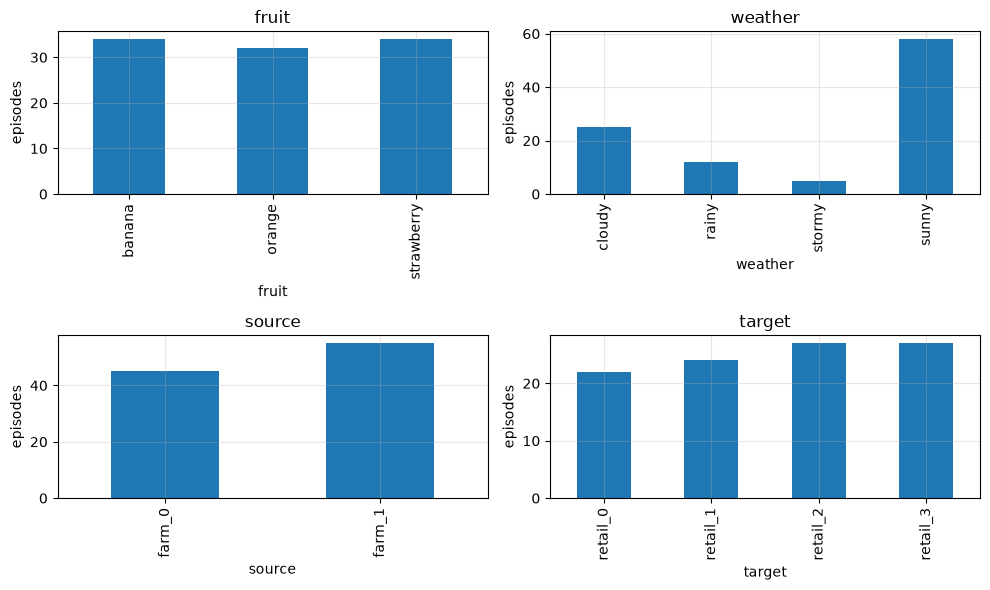

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, col in zip(axes.flatten(), ["fruit", "weather", "source", "target"]):
    episodes_df[col].value_counts().sort_index().plot.bar(ax=ax, color="tab:blue")
    ax.set(title=col, ylabel="episodes")
fig.tight_layout()
plt.show()

## Label distribution

label counts:
fresh (0)      40
spoiled (1)    60
Name: count, dtype: int64


final_label,fresh,spoiled,spoiled_rate
fruit,,,
banana,15,19,0.559
orange,17,15,0.469
strawberry,8,26,0.765


final_label,fresh,spoiled,spoiled_rate
weather,,,
cloudy,8,17,0.680
rainy,6,6,0.500
stormy,3,2,0.400
sunny,23,35,0.603


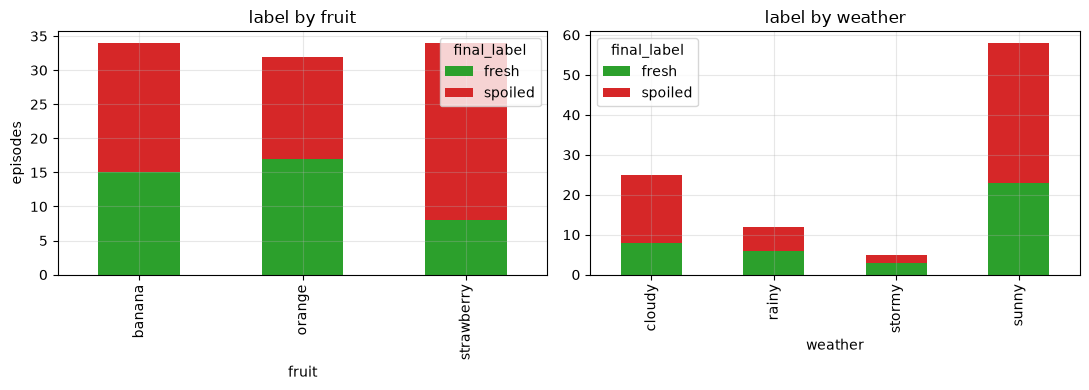

In [5]:
def label_breakdown(by: str) -> pd.DataFrame:
    tab = (
        episodes_df.groupby(by)["final_label"]
        .value_counts()
        .unstack(fill_value=0)
        .rename(columns={0: "fresh", 1: "spoiled"})
        .sort_index()
    )
    tab["spoiled_rate"] = tab["spoiled"] / tab.sum(axis=1)
    return tab


overall = episodes_df["final_label"].value_counts().sort_index()
overall.index = ["fresh (0)", "spoiled (1)"][:len(overall)]
by_fruit = label_breakdown("fruit")
by_weather = label_breakdown("weather")

print("label counts:")
print(overall)
display(by_fruit.round(3))
display(by_weather.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
by_fruit[["fresh", "spoiled"]].plot.bar(stacked=True, ax=axes[0], color=["tab:green", "tab:red"])
axes[0].set(title="label by fruit", ylabel="episodes")
by_weather[["fresh", "spoiled"]].plot.bar(stacked=True, ax=axes[1], color=["tab:green", "tab:red"])
axes[1].set(title="label by weather")
fig.tight_layout()
plt.show()

## Delivery rate by fruit

,delivered_rate,episodes
fruit,,
banana,0.412,34
orange,0.312,32
strawberry,0.235,34


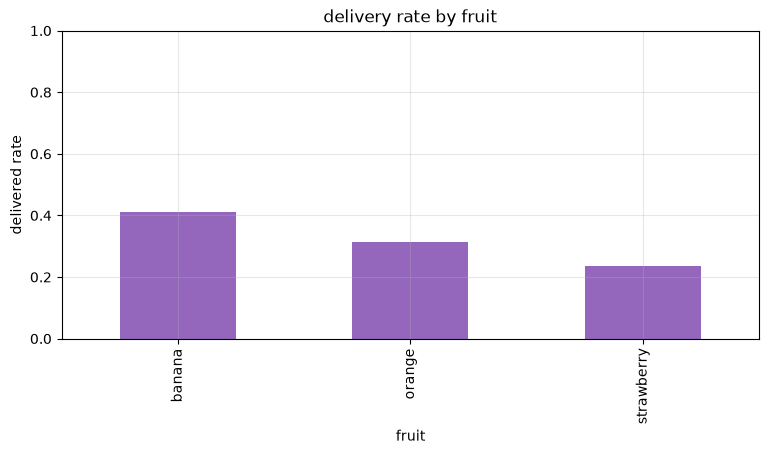

In [6]:
delivery_by_fruit = (
    episodes_df.groupby("fruit")["delivered"].agg(["mean", "count"])
    .rename(columns={"mean": "delivered_rate", "count": "episodes"})
)
display(delivery_by_fruit.round(3))

fig, ax = plt.subplots()
delivery_by_fruit["delivered_rate"].plot.bar(ax=ax, color="tab:purple")
ax.set(ylim=(0, 1), ylabel="delivered rate", title="delivery rate by fruit")
plt.show()

## Spoilage-risk trajectory (by episode progress)

,mean,std,count
rel_bin,,,
0,0.092,0.063,162
1,0.233,0.142,104
2,0.323,0.189,121
3,0.396,0.239,123
4,0.533,0.253,95
5,0.587,0.266,124
6,0.615,0.298,130
7,0.736,0.252,114
8,0.790,0.239,111


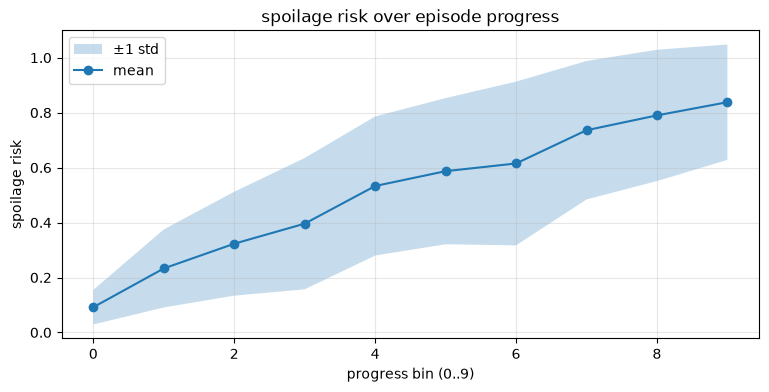

In [7]:
overall_traj = steps_df.groupby("rel_bin")["spoilage_risk"].agg(["mean", "std", "count"]).round(3)
display(overall_traj)

fig, ax = plt.subplots()
ax.fill_between(overall_traj.index,
                overall_traj["mean"] - overall_traj["std"],
                overall_traj["mean"] + overall_traj["std"],
                alpha=0.25, label="±1 std")
ax.plot(overall_traj.index, overall_traj["mean"], marker="o", label="mean")
ax.set(xlabel=f"progress bin (0..{BINS - 1})", ylabel="spoilage risk",
       title="spoilage risk over episode progress")
ax.legend()
plt.show()

## Sensor temperature by fruit

,count,mean,std,min,25%,50%,75%,max
fruit,,,,,,,,
banana,326.0,3.27,9.87,-21.60,-4.10,3.77,10.75,22.82
orange,383.0,1.49,9.83,-20.08,-6.09,1.18,8.90,25.09
strawberry,452.0,1.37,9.32,-20.72,-5.80,1.18,8.02,25.00


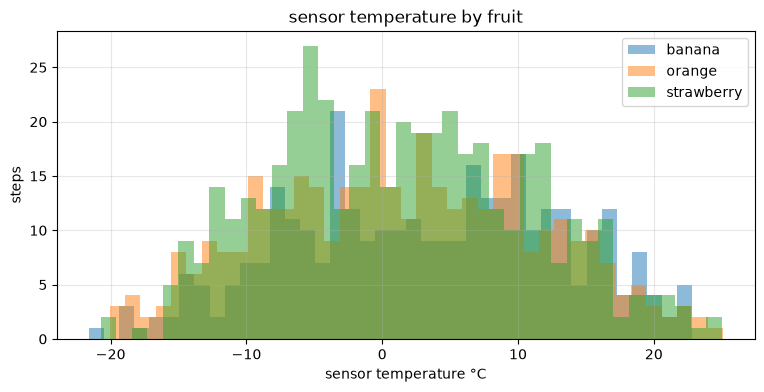

In [8]:
display(steps_df.groupby("fruit")["sensor_temperature_c"].describe().round(2))

fig, ax = plt.subplots()
for fruit, group in steps_df.groupby("fruit"):
    ax.hist(group["sensor_temperature_c"], bins=40, alpha=0.5, label=fruit)
ax.set(xlabel="sensor temperature °C", ylabel="steps", title="sensor temperature by fruit")
ax.legend()
plt.show()

## Actions

,routing,delivery_0,delivery_1,delivery_2
0,229,280,312,277
1,235,299,260,300
2,219,289,285,317
3,238,293,304,267
4,240,0,0,0


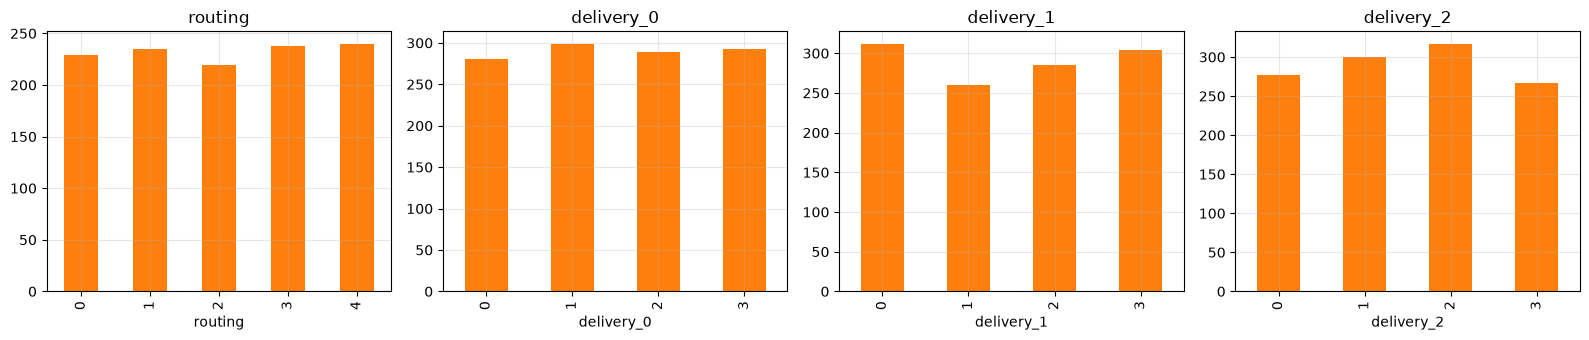

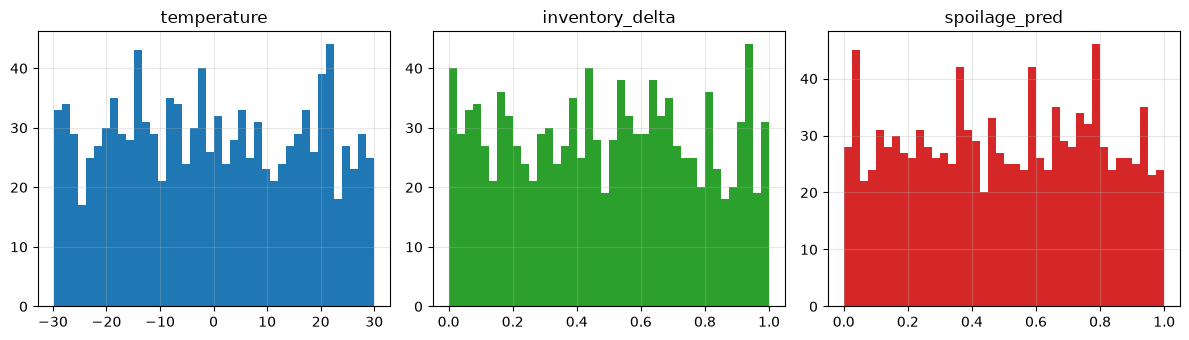

,temperature,inventory_delta,spoilage_pred
count,1161.000,1161.000,1161.000
mean,-0.352,0.491,0.498
std,17.175,0.290,0.287
min,-29.848,0.000,0.000
25%,-14.829,0.234,0.248
50%,-0.993,0.499,0.501
75%,15.179,0.726,0.747
max,29.955,1.000,0.999


In [9]:
from core.config import DELIVERY_AGENTS

action_rows = []
for ep in dataset:
    for step in ep.steps:
        a = step.actions
        action_rows.append({
            "routing": int(a["routing"]),
            **{name: int(a[name]) for name in DELIVERY_AGENTS},
            "spoilage_pred": float(np.asarray(a["spoilage"]).flatten()[0]),
            "temperature": float(np.asarray(a["temperature"]).flatten()[0]),
            "inventory_delta": float(np.asarray(a["inventory"]).flatten()[0]),
        })
actions_df = pd.DataFrame(action_rows)

discrete = ["routing", *DELIVERY_AGENTS]
display(pd.DataFrame({
    col: actions_df[col].value_counts().sort_index() for col in discrete
}).fillna(0).astype(int))

fig, axes = plt.subplots(1, len(discrete), figsize=(4 * len(discrete), 3.5))
for ax, col in zip(axes, discrete):
    actions_df[col].value_counts().sort_index().plot.bar(ax=ax, color="tab:orange")
    ax.set_title(col)
fig.tight_layout()
plt.show()

continuous = ["temperature", "inventory_delta", "spoilage_pred"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col, color in zip(axes, continuous, ["tab:blue", "tab:green", "tab:red"]):
    ax.hist(actions_df[col], bins=40, color=color)
    ax.set_title(col)
fig.tight_layout()
plt.show()

display(actions_df[continuous].describe().round(3))

## Disruptions

active disruptions across all steps:
type
increased_transit_time    185
blocked_node              149
risk_flag                  55
Name: count, dtype: int64

episodes with ≥1 active disruption: 39 / 100


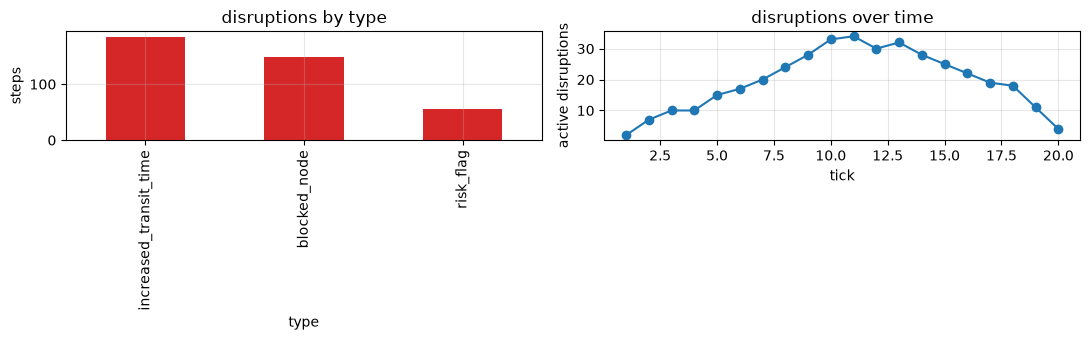

In [10]:
disruption_rows = []
for ep in dataset:
    for step in ep.steps:
        for d in step.active_disruptions:
            disruption_rows.append({"episode_id": ep.episode_id, "tick": step.tick, "type": d.type.value})
disruptions_df = pd.DataFrame(disruption_rows)

if disruptions_df.empty:
    print("no disruptions in dataset")
else:
    type_counts = disruptions_df["type"].value_counts()
    print("active disruptions across all steps:")
    print(type_counts)
    episodes_with = disruptions_df["episode_id"].nunique()
    print(f"\nepisodes with ≥1 active disruption: {episodes_with} / {len(dataset)}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    type_counts.plot.bar(ax=axes[0], color="tab:red")
    axes[0].set(title="disruptions by type", ylabel="steps")
    disruptions_df.groupby("tick").size().plot(ax=axes[1], marker="o")
    axes[1].set(xlabel="tick", ylabel="active disruptions", title="disruptions over time")
    fig.tight_layout()
    plt.show()

## Energy & observation health (NaN / Inf)

,energy/step
count,1161.000
mean,1.906
std,1.065
min,0.000
25%,1.094
50%,1.857
75%,2.714
max,4.521


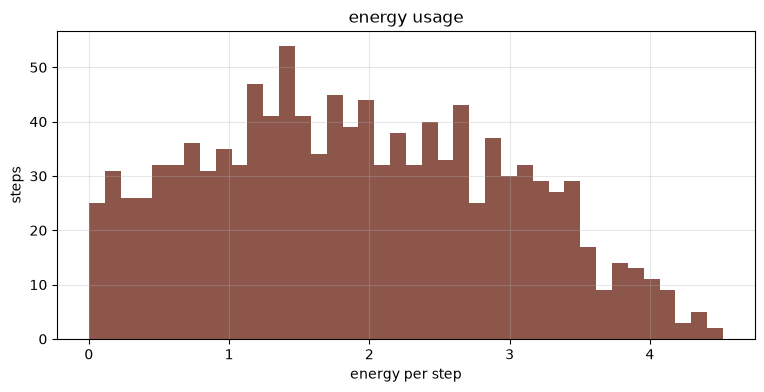

,steps,nan_steps,inf_steps,obs_min,obs_max
agent,,,,,
delivery_0,1161,0,0,0.000,1.000
delivery_1,1161,0,0,0.000,1.000
delivery_2,1161,0,0,0.000,1.000
inventory,1161,0,0,0.000,27.000
routing,1161,0,0,0.000,3.000
spoilage,1161,0,0,-21.601,29.080
temperature,1161,0,0,-29.848,29.955


In [11]:
display(steps_df["energy_usage"].describe().round(3).to_frame("energy/step"))

fig, ax = plt.subplots()
ax.hist(steps_df["energy_usage"], bins=40, color="tab:brown")
ax.set(xlabel="energy per step", ylabel="steps", title="energy usage")
plt.show()

health_rows = []
for ep in dataset:
    for step in ep.steps:
        for agent, arr in step.observations.items():
            health_rows.append({
                "agent": agent,
                "has_nan": bool(np.isnan(arr).any()),
                "has_inf": bool(np.isinf(arr).any()),
                "min": float(arr.min()),
                "max": float(arr.max()),
            })
health = pd.DataFrame(health_rows).groupby("agent").agg(
    steps=("has_nan", "size"),
    nan_steps=("has_nan", "sum"),
    inf_steps=("has_inf", "sum"),
    obs_min=("min", "min"),
    obs_max=("max", "max"),
).round(3)
display(health)

## Train/val split preview

In [12]:
train, val = dataset.train_val_split(val_fraction=0.2, seed=0)
print(f"train: {len(train)} episodes | val: {len(val)} episodes")
print(f"train ids (first 10): {list(train.episode_ids())[:10]}")
print(f"val ids: {list(val.episode_ids())}")

train: 80 episodes | val: 20 episodes
train ids (first 10): [0, 1, 2, 3, 4, 6, 7, 12, 14, 15]
val ids: [5, 8, 9, 10, 11, 13, 16, 20, 27, 36, 37, 52, 72, 75, 81, 82, 83, 90, 93, 94]
